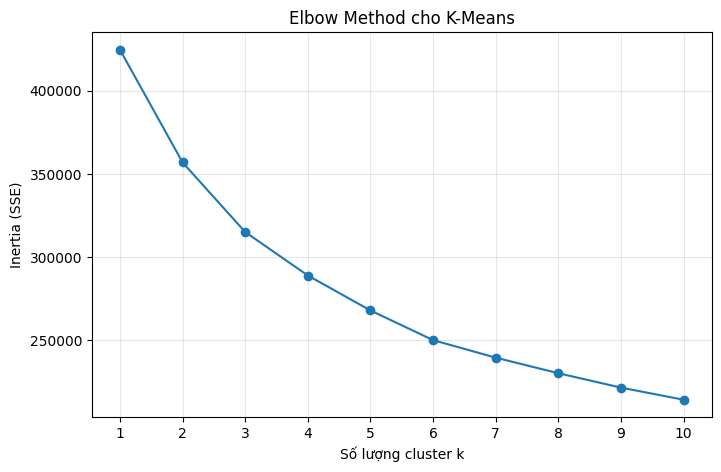

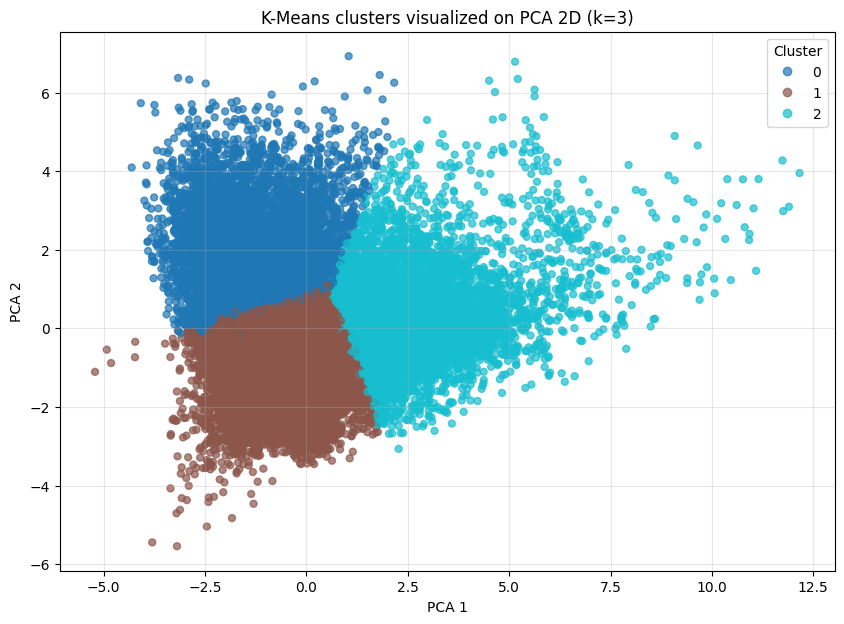

Cluster centroids (original scale):
            aqi      co    no2      o3    pm10   pm25    so2  clouds  \
cluster                                                                
0        112.02  190.05  13.71  111.41   52.39  40.00  73.50   57.50   
1         97.13  442.82  24.54   42.16   45.27  33.34  49.06   74.86   
2        194.93  381.98  47.98   40.85  139.53  99.97  83.61   75.21   

         precipitation  pressure  relative_humidity  temperature  uv_index  \
cluster                                                                      
0                 0.12   1007.42              61.09        29.74      3.52   
1                 0.37   1008.33              84.88        25.04      0.64   
2                 0.08   1016.56              76.98        19.91      0.76   

         wind_speed  
cluster              
0              2.05  
1              1.81  
2              1.46  

Cluster size:
cluster
0     6892
1    16236
2     7213
Name: count, dtype: int64

Mean AQI by cluster

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dữ liệu đã làm sạch
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv', low_memory=False, on_bad_lines='skip')
except Exception as e:
    print(f"Error reading cleaned file: {e}")
    # Fallback: load and combine raw data
    files = ['../data_raw/2022.csv', '../data_raw/2023.csv', '../data_raw/2024.csv', '../data_raw/2025.csv']
    df_list = []
    for f in files:
        try:
            df_list.append(pd.read_csv(f, low_memory=False, on_bad_lines='skip'))
        except:
            pass
    df = pd.concat(df_list, ignore_index=True)

df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Chọn các đặc trưng số để clustering, loại bỏ các cột thời gian và categorical
exclude_cols = ['year', 'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'season']
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols and c in df.columns]
X = df[feature_cols].dropna()

# 11. StandardScaler trước khi clustering
scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(X)

# 12. Elbow method để tìm số cluster tối ưu
inertia = []
ks = list(range(1, 11))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_std)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertia, marker='o')
plt.xticks(ks)
plt.xlabel('Số lượng cluster k')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method cho K-Means')
plt.grid(alpha=0.3)
plt.show()

# Chọn k tối ưu từ elbow plot
k_opt = 3
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled_std)

# 13. Visualize cluster trên PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_std)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=25, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'K-Means clusters visualized on PCA 2D (k={k_opt})')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.grid(alpha=0.3)
plt.show()

# 14. Phân tích đặc trưng từng cluster
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=X.columns
)
cluster_centers.index.name = 'cluster'
cluster_centers['cluster'] = range(k_opt)
cluster_centers = cluster_centers.set_index('cluster')
print('Cluster centroids (original scale):')
print(cluster_centers.round(2))

# Gắn nhãn cluster vào bản gốc để phân tích theo mùa / giờ
clustered_df = df.loc[X.index].copy()
clustered_df['cluster'] = labels

# Sử dụng cột hour có sẵn nếu có
if 'hour' in clustered_df.columns:
    clustered_df['hour'] = clustered_df['hour']
else:
    if 'date' in clustered_df.columns:
        clustered_df['hour'] = clustered_df['date'].dt.hour

# Sử dụng cột month nếu có, hoặc trích xuất từ date
if 'month' in clustered_df.columns:
    clustered_df['month'] = clustered_df['month']
else:
    if 'date' in clustered_df.columns:
        clustered_df['month'] = clustered_df['date'].dt.month

SEASON_MAP = {0: 'Đông', 1: 'Xuân', 2: 'Hè', 3: 'Thu'}
if 'season' in clustered_df.columns:
    clustered_df['season_name'] = clustered_df['season'].map(SEASON_MAP)
elif 'month' in clustered_df.columns:
    clustered_df['season_name'] = pd.cut(
        clustered_df['month'],
        bins=[0, 3, 6, 9, 12],
        labels=['Đông', 'Xuân', 'Hè', 'Thu'],
        right=True
    )

print('\nCluster size:')
print(clustered_df['cluster'].value_counts().sort_index())

if 'aqi' in clustered_df.columns:
    print('\nMean AQI by cluster:')
    print(clustered_df.groupby('cluster')['aqi'].mean().round(2))

if 'season_name' in clustered_df.columns:
    print('\nCluster distribution by season:')
    print(clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0))

if 'hour' in clustered_df.columns:
    print('\nCluster distribution by hour:')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts)
    top_hours = hour_counts.idxmax(axis=1)
    print('\nHour with most members in each cluster:')
    print(top_hours)

# Nếu có AQI, đánh giá cluster nào ô nhiễm nhất
if 'aqi' in clustered_df.columns:
    aqi_cluster = clustered_df.groupby('cluster')['aqi'].mean().sort_values(ascending=False)
    print('\nClusters ranked by mean AQI:')
    print(aqi_cluster.round(2))